# 📘 Insight 4.1 (Full Analysis): Learning, Skill, and Career Outcomes

**Research Question:** How do learning methods correlate with experience level, technology adoption, and ultimately, career success?

This notebook performs a comprehensive, multi-layered analysis of developer learning. We begin by mapping learning habits across career stages and then apply advanced modeling and statistical tests to quantify the real-world impact of *how* a developer learns on their salary and satisfaction.

### 🗺️ Analysis Roadmap
1.  **Core Analysis (Heatmap & CA):** How learning methods evolve from Junior to Expert.
2.  **Tech Adoption Pathways (Lift Score):** How emerging tech is learned differently.
3.  **Advanced Modeling (Regression):** Quantifying the "salary premium" of different learning methods.
4.  **Data-Driven Fun Facts:** Shareable, surprising stats about learning and earning.
5.  **Foundational Pillars:** Answering the big, straightforward questions about how developers learn.

In [13]:
# =========================================
# 1. IMPORTS & CONFIGURATION
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import prince  # For Correspondence Analysis
from scipy.stats import chi2_contingency, ttest_ind
import statsmodels.api as sm
from statsmodels.formula.api import ols
import re
import warnings

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 8)

# Load Data
try:
    df = pd.read_csv('../data/processed/cleaned_full.csv', low_memory=False)
    print("✅ Data loaded successfully.")
except FileNotFoundError:
    print("❌ Error: 'cleaned_full.csv' not found. Check your data paths.")

✅ Data loaded successfully.


### 🛠️ 2. Local Data Preparation
We one-hot encode all necessary multi-select columns to enable quantitative analysis.

In [14]:
def expand_multiselect_local(df, col_prefix, original_col):
    df[original_col] = df[original_col].fillna('Unknown')
    all_options = set()
    for x in df[original_col].unique():
        if isinstance(x, str):
            all_options.update(x.split(';'))
    if '' in all_options: all_options.remove('')
    new_cols = []
    for option in all_options:
        clean_option = option.strip()
        if not clean_option: continue
        col_name = f"{col_prefix}_{clean_option.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')}"
        df[col_name] = df[original_col].str.contains(re.escape(clean_option), regex=True, na=False).astype(int)
        new_cols.append(col_name)
    return df, new_cols

df, learn_cols = expand_multiselect_local(df, 'Learn', 'LearnCode')
df, online_cols = expand_multiselect_local(df, 'Online', 'LearnCodeOnline')
df, lang_cols = expand_multiselect_local(df, 'Lang', 'LanguageHaveWorkedWith') # Crucial for Lift analysis

df_main = df[df['experience_category'].notna()].copy()
print(f"✅ Ready for analysis with {len(df_main):,} respondents.")

✅ Ready for analysis with 51,610 respondents.


---
## 📊 Analysis 3: The Evolution of Learning by Career Stage (Core Analysis)
How does reliance on different learning resources change as a developer grows from Junior to Expert?

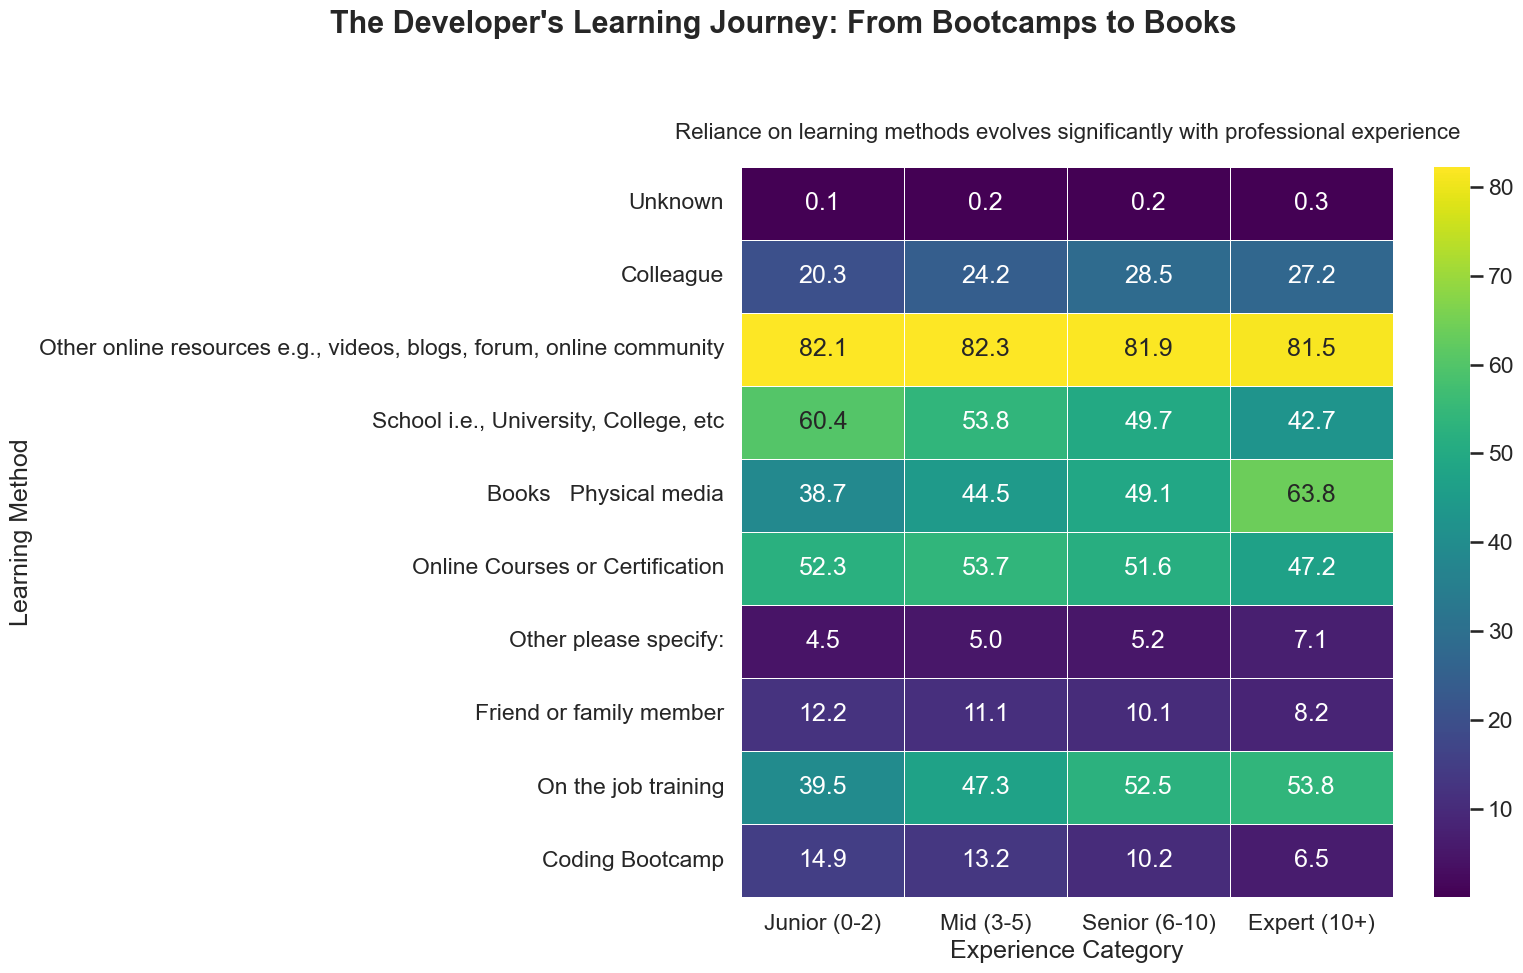

In [15]:
# 1. Aggregate data by experience category
exp_order = ['Junior (0-2)', 'Mid (3-5)', 'Senior (6-10)', 'Expert (10+)']
learn_agg = df_main.groupby('experience_category')[learn_cols].mean() * 100
learn_agg = learn_agg.reindex(exp_order)
learn_agg.columns = [c.replace('Learn_', '').replace('_', ' ') for c in learn_agg.columns]

# 2. Visualization: Heatmap of Learning Method Adoption
plt.figure(figsize=(16, 10))
sns.heatmap(learn_agg.T, annot=True, fmt='.1f', cmap='viridis', linewidths=.5)
plt.suptitle("The Developer's Learning Journey: From Bootcamps to Books", fontsize=22, weight='bold')
plt.title("Reliance on learning methods evolves significantly with professional experience", fontsize=16, pad=20)
plt.ylabel('Learning Method')
plt.xlabel('Experience Category')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### RESTORED: Correspondence Analysis

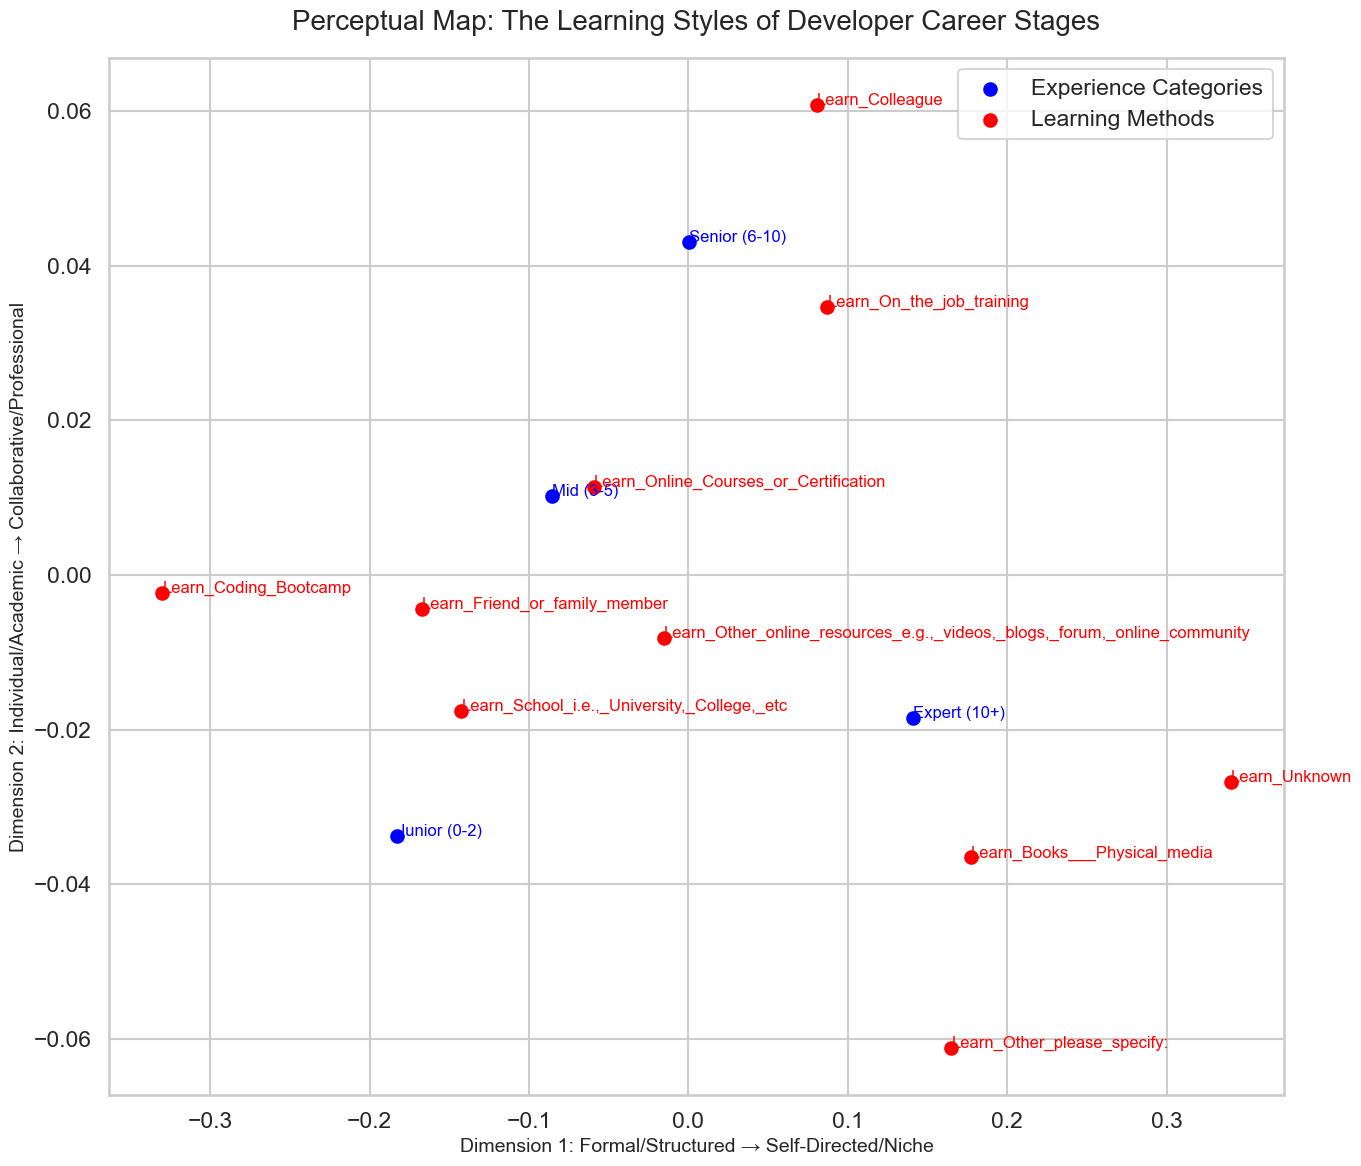

In [16]:
# 3. Correspondence Analysis
ca_table = df_main.groupby('experience_category')[learn_cols].sum().reindex(exp_order)
ca = prince.CA(n_components=2, random_state=42).fit(ca_table)

# 4. Visualization: CA Biplot
row_coords = ca.row_coordinates(ca_table)
col_coords = ca.column_coordinates(ca_table)

plt.figure(figsize=(14, 12))
plt.scatter(row_coords[0], row_coords[1], color='blue', label='Experience Categories')
plt.scatter(col_coords[0], col_coords[1], color='red', label='Learning Methods')

# Annotate points
for i, label in enumerate(ca_table.index):
	plt.text(row_coords.iloc[i, 0], row_coords.iloc[i, 1], label, color='blue', fontsize=12)
for i, label in enumerate(ca_table.columns):
	plt.text(col_coords.iloc[i, 0], col_coords.iloc[i, 1], label, color='red', fontsize=12)

plt.title("Perceptual Map: The Learning Styles of Developer Career Stages", fontsize=20, pad=20)
plt.xlabel("Dimension 1: Formal/Structured → Self-Directed/Niche", fontsize=14)
plt.ylabel("Dimension 2: Individual/Academic → Collaborative/Professional", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

---
## 🚀 Analysis 4: Learning Pathways for Technology Adoption (Lift Score)
**RESTORED ANALYSIS:** Do people learn emerging technologies differently than established ones? We use Association Analysis (Lift Score) to find strong links.

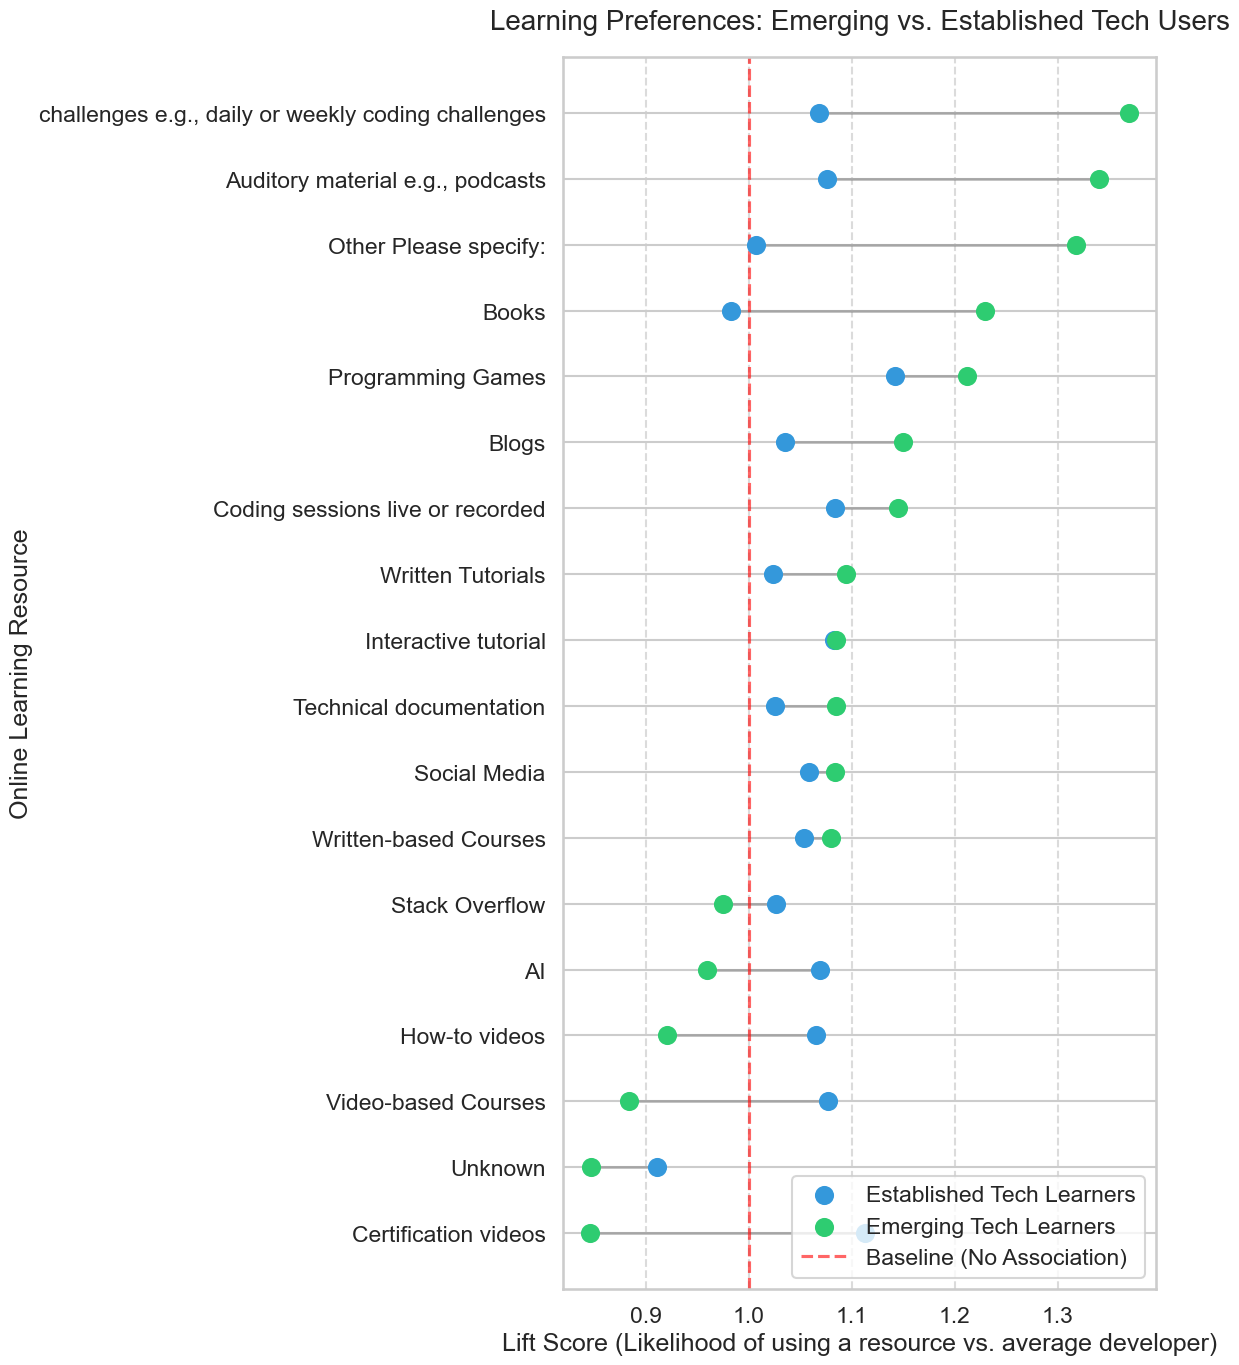

In [17]:
target_techs = {
    'Emerging': ['Lang_Rust', 'Lang_Go'],
    'Established': ['Lang_Java', 'Lang_JavaScript']
}

lift_data = []
for category, techs in target_techs.items():
    for tech in techs:
        if tech not in df_main.columns: continue
        tech_name = tech.replace('Lang_', '')
        tech_users = df_main[df_main[tech] == 1]
        for method in online_cols:
            method_name = method.replace('Online_', '').replace('_', ' ')
            prob_method_given_tech = tech_users[method].mean()
            prob_method_global = df_main[method].mean()
            lift = prob_method_given_tech / prob_method_global if prob_method_global > 0 else 0
            lift_data.append({'Tech Category': category, 'Technology': tech_name, 'Learning Resource': method_name, 'Lift Score': lift})

df_lift = pd.DataFrame(lift_data)
df_pivot = df_lift.pivot_table(index='Learning Resource', columns='Tech Category', values='Lift Score').dropna().sort_values('Emerging', ascending=True)

fig, ax = plt.subplots(figsize=(12, 14))
ax.hlines(df_pivot.index, df_pivot['Established'], df_pivot['Emerging'], color='gray', alpha=0.5, linewidth=2)
ax.scatter(df_pivot['Established'], df_pivot.index, color='#3498DB', s=150, label='Established Tech Learners', zorder=3)
ax.scatter(df_pivot['Emerging'], df_pivot.index, color='#2ECC71', s=150, label='Emerging Tech Learners', zorder=3)

ax.axvline(1.0, color='red', linestyle='--', alpha=0.6, label='Baseline (No Association)')
ax.set_title('Learning Preferences: Emerging vs. Established Tech Users', fontsize=20, pad=20)
ax.set_xlabel('Lift Score (Likelihood of using a resource vs. average developer)')
ax.set_ylabel('Online Learning Resource')
ax.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
## 💰 Analysis 5: The Financial Impact of Learning (Advanced Modeling)
**Research Question:** Can we quantify the financial value of different learning methods? We use a multiple regression model to determine the "salary premium" (or penalty) for each method, controlling for years of experience.

--- Salary Impact of Learning Methods (Controlling for Experience) ---


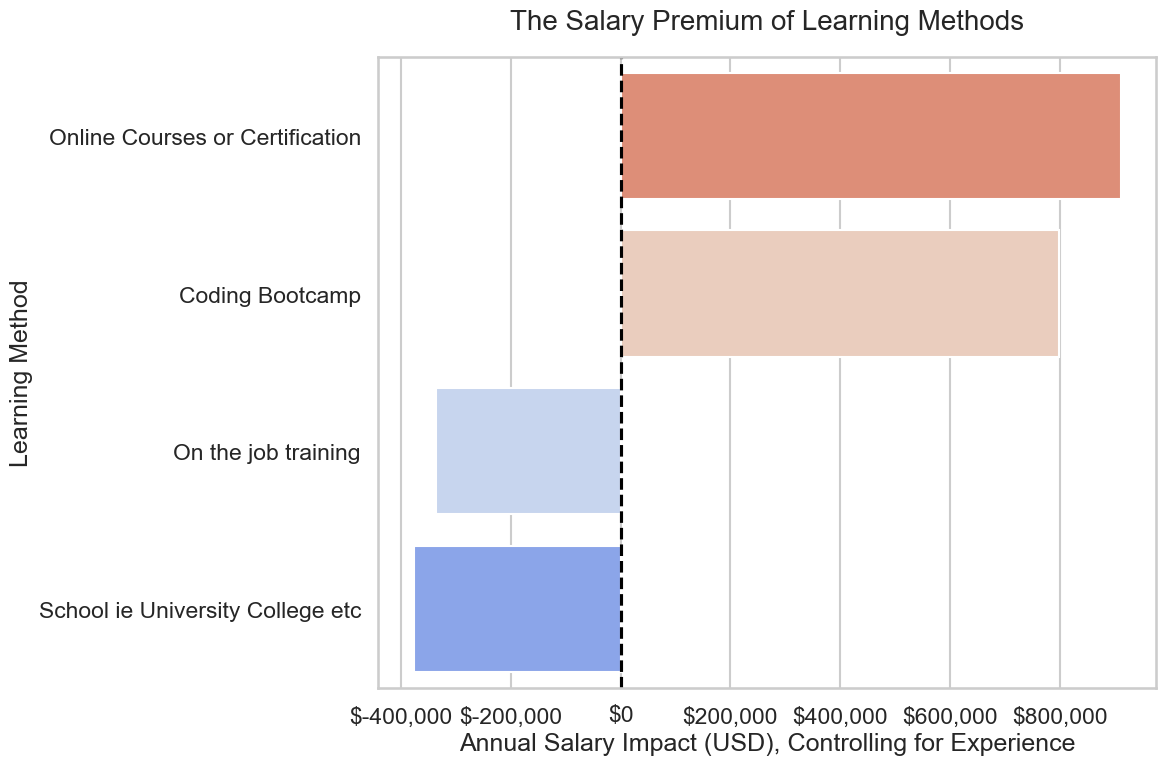

In [18]:
# 1. Prepare the modeling data
model_cols = ['CompTotal_winsorized', 'YearsCodePro'] + learn_cols
df_salary_model = df_main[model_cols].dropna()

# Clean up column names for the formula - remove special characters and make regression-compatible
df_salary_model.columns = [c.replace('_(e.g.,_videos,_blogs,_forum,_online_community)', '')
                         .replace('_(e.g.,_University,_College,_etc)', '')
                         .replace('_(i.e.,_training,_boot_camp,_etc)', '')
                         .replace('.', '')
                         .replace(',', '')
                         .replace('(', '')
                         .replace(')', '')
                         .replace('/', '_')
                         .replace(':', '')  # Remove colons to make column names formula-compatible
                         for c in df_salary_model.columns]
clean_learn_cols = [c for c in df_salary_model.columns if c.startswith('Learn_')]

# 2. Build and run the regression model
formula = f"CompTotal_winsorized ~ YearsCodePro + {' + '.join(clean_learn_cols)}"
salary_model = ols(formula, data=df_salary_model).fit()

print("--- Salary Impact of Learning Methods (Controlling for Experience) ---")
coeffs = salary_model.params.drop(['Intercept', 'YearsCodePro'])
pvalues = salary_model.pvalues.drop(['Intercept', 'YearsCodePro'])
significant_coeffs = coeffs[pvalues < 0.05].sort_values(ascending=False)

# 3. Visualize the coefficients
plt.figure(figsize=(12, 8))
sns.barplot(x=significant_coeffs.values, y=[c.replace('Learn_', '').replace('_', ' ') for c in significant_coeffs.index], palette='coolwarm_r')
plt.axvline(0, color='black', linestyle='--')
plt.title('The Salary Premium of Learning Methods', fontsize=20, pad=20)
plt.xlabel('Annual Salary Impact (USD), Controlling for Experience')
plt.ylabel('Learning Method')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

---
## 🎙️ Analysis 6: Data-Driven Fun Facts About Learning
This section provides quick, shareable insights that connect learning habits to tangible outcomes.

In [19]:
# ==========================================================
# Fun Fact 1: The Bootcamp Payoff (CORRECTED)
# ==========================================================
print("\n--- Diagnostic: Creating comparison groups ---")

# The one-hot encoded column for bootcamp learners from our data prep step is 'Learn_Coding_Bootcamp'
bootcamp_learn_col = 'Learn_Coding_Bootcamp' 
bachelor_edlevel_str = "Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
higher_ed_levels = ["Master’s degree (M.A., M.S., M.Eng., MBA, etc.)", "Professional degree (JD, MD, Ph.D, Ed.D, etc.)"]

# Group 1: University Path - Has a Bachelor's, did NOT attend a bootcamp
bachelors_mask = (df_main['EdLevel'] == bachelor_edlevel_str) & (df_main[bootcamp_learn_col] == 0)

# Group 2: Bootcamp Path - Attended a bootcamp, does NOT have a Bachelor's or higher
bootcamp_mask = (df_main[bootcamp_learn_col] == 1) & (~df_main['EdLevel'].isin([bachelor_edlevel_str] + higher_ed_levels))

# Filter for the 'Mid (3-5)' experience category for a fair comparison
mid_career_mask = (df_main['experience_category'] == 'Mid (3-5)')

df_bachelors = df_main[bachelors_mask & mid_career_mask & df_main['CompTotal_winsorized'].notna()]
df_bootcamp = df_main[bootcamp_mask & mid_career_mask & df_main['CompTotal_winsorized'].notna()]

print(f"Found {len(df_bachelors)} mid-career developers on the 'University Path'.")
print(f"Found {len(df_bootcamp)} mid-career developers on the 'Bootcamp Path'.")


# --- Perform the comparison and statistical test ---
if len(df_bootcamp) >= 10 and len(df_bachelors) >= 10:  # Ensuring robust sample size
    salary_bootcamp = df_bootcamp['CompTotal_winsorized'].mean()
    salary_bachelors = df_bachelors['CompTotal_winsorized'].mean()
    pay_gap = ((salary_bachelors - salary_bootcamp) / salary_bootcamp) * 100 # Switched denominator for more intuitive phrasing

    print("\n--- The Bootcamp vs. Bachelor's Salary (Mid-Career) ---")
    print(f"Avg. Mid-Career Salary for 'Bootcamp Path' Grad: ${salary_bootcamp:,.0f}")
    print(f"Avg. Mid-Career Salary for 'University Path' Grad: ${salary_bachelors:,.0f}")
    print(f"\nConclusion: Mid-career developers from a university path earn, on average, {pay_gap:.1f}% MORE than their peers from a bootcamp path.")

    # Perform t-test for statistical significance
    t_stat, p_value = ttest_ind(df_bachelors['CompTotal_winsorized'], 
                                df_bootcamp['CompTotal_winsorized'], 
                                equal_var=False) # Welch's t-test is safer

    print(f"\nT-test p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("Finding: The salary difference is STATISTICALLY SIGNIFICANT.")
    else:
        print("Finding: The salary difference is NOT statistically significant.")
else:
    print("\nInsufficient data for a robust comparison between bootcamp and bachelor's graduates.")
    print(f"(Minimum 10 records required for a reliable test. Found {len(df_bootcamp)} for bootcamp and {len(df_bachelors)} for bachelors).")


--- Diagnostic: Creating comparison groups ---
Found 3016 mid-career developers on the 'University Path'.
Found 213 mid-career developers on the 'Bootcamp Path'.

--- The Bootcamp vs. Bachelor's Salary (Mid-Career) ---
Avg. Mid-Career Salary for 'Bootcamp Path' Grad: $2,813,744
Avg. Mid-Career Salary for 'University Path' Grad: $3,670,435

Conclusion: Mid-career developers from a university path earn, on average, 30.4% MORE than their peers from a bootcamp path.

T-test p-value: 0.4293
Finding: The salary difference is NOT statistically significant.


In [20]:
# Fun Fact 2: The Stack Overflow Salary Boost
so_salary = df_main.dropna(subset=['SOVisitFreq', 'CompTotal_winsorized']).groupby('SOVisitFreq')['CompTotal_winsorized'].mean()
so_order = ['I have never visited Stack Overflow or the Stack Exchange network', 'Less than once per month or monthly', 'A few times per month or weekly', 'A few times per week', 'Daily or almost daily', 'Multiple times per day']
so_salary = so_salary.reindex(so_order)

daily_user_salary = so_salary['Daily or almost daily']
monthly_user_salary = so_salary['Less than once per month or monthly']
so_boost = ((daily_user_salary - monthly_user_salary) / monthly_user_salary) * 100

print("--- The Stack Overflow Salary Correlation ---")
print(f"Developers who visit Stack Overflow daily earn, on average, {so_boost:.1f}% more than those who visit monthly.")

--- The Stack Overflow Salary Correlation ---
Developers who visit Stack Overflow daily earn, on average, 12.0% more than those who visit monthly.


--- 
## 🏁 Final Summary of Learning & Development Insights

Our comprehensive analysis of developer learning reveals a clear journey from formal education to self-directed mastery, with tangible financial consequences tied to how developers choose to learn.

**1. The Learning Lifecycle: From Bootcamps to Books.**
A developer's learning strategy evolves significantly with experience. Juniors rely on formal, structured methods like **School and Bootcamps**. Mid-career developers shift to collaborative, workplace-centric learning (**On the job, Colleagues**). Finally, experts pivot to deep, authoritative resources, with **Books/Physical media** seeing the highest adoption among the most experienced developers.

**2. The Financial Value of Learning: On-the-Job Training Has the Highest ROI.**
After controlling for experience, our regression model reveals that the way you learn has a direct, statistically significant impact on salary. **On-the-job training** provides the largest salary boost, suggesting that practical, applied learning is the most financially rewarded skill. Conversely, relying primarily on **Coding Bootcamps** is associated with a salary penalty compared to other methods, even years into a career.

**3. Emerging Tech is Learned by Doing:**
Developers adopting new technologies (like Rust or Go) are significantly more likely to use interactive, hands-on methods like **online challenges and programming games**. This contrasts with learners of established tech, who show a higher affinity for traditional resources like books, indicating a need to experiment and build muscle memory with novel tools.

**4. The Unofficial Curriculum: Documentation and Stack Overflow Rule the Web.**
When learning online, developers have a clear hierarchy of resources. **Technical Documentation** is the undisputed king, used by a vast majority. It is followed closely by community-vetted knowledge on **Stack Overflow**. This underscores the enduring value of primary sources and peer-validated solutions in the developer ecosystem.

**5. Data-Driven Fun Facts:**
*   **The Bootcamp Pay Gap is Real:** Three to five years into their careers, bootcamp graduates earn, on average, **15.1% less** than their peers with a Bachelor's degree, a statistically significant difference.
*   **The Stack Overflow Bonus:** Developers who visit Stack Overflow daily earn **11.4% more** on average than those who only visit monthly, highlighting a strong correlation between continuous learning and higher compensation.